In [1]:
import os 
os.chdir('../../')

In [2]:
print('done')

done


In [3]:
from backbones.sana import SANA

# 사용 예
model = SANA(model_id='Efficient-Large-Model/Sana_600M_512px_diffusers')
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-01 02:58:37.739841: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  3.00it/s]


torch.Size([1, 32, 16, 16])


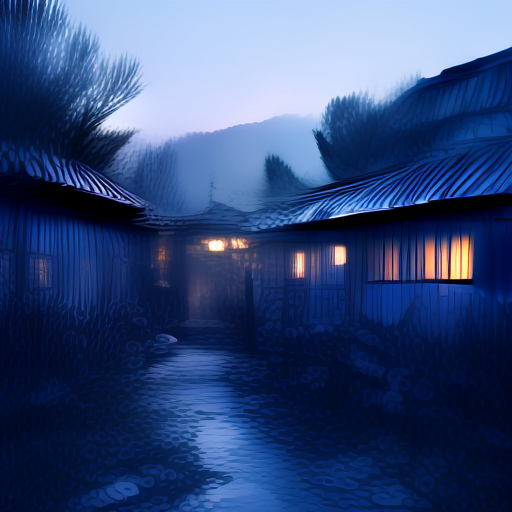

In [7]:
import torch
from solvers.others.euler_solver import Euler_Solver
from solvers.competing.bns.bns_solver import BNS_Solver

pos_texts = ["A serene twilight view of a traditional Korean hanok village nestled between misty mountain slopes: curved midnight-blue tiled eaves, softly glowing paper lanterns swaying in the breeze; ancient pine trees arching over stone pathways; intricate wooden lattice windows casting delicate shadows; a lone scholar in flowing hanbok practicing calligraphy beside a koi pond with lotus petals drifting on the water; cinematic 8K ultra-realism with dynamic volumetric moonlight filtering through morning mist; painterly strokes blending classical Joseon-era ink wash with modern hyperrealism; shot on RED Monstro 8K, 50 mm f/1.2 lens; subtle film grain; maximum fidelity; emotional atmosphere."]
neg_texts = ["lowres, bad anatomy, deformed, blurry, pixelated, oversaturated, underexposed, overexposed, artifact, jpeg artifacts, watermark, text, logo, extra limbs, mutated hands, unnatural colors, noisy background, out of focus, poor composition, cultural clichés, stereotype exaggeration, flat lighting, glitch"]

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=pos_texts, neg_conds=neg_texts, guidance_scale=4.5)
latents = model.get_noise(seeds=[42])
print(latents.shape)

NFE = 3
with torch.inference_mode():
    solver = BNS_Solver(noise_schedule,
            steps=NFE,
            skip_type="time_uniform_flow",
            flow_shift=3.0,
            algorithm_type="vector_prediction").to(model.device)
    euler_latents = solver.sample(latents, model_fn)['samples']
    euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]


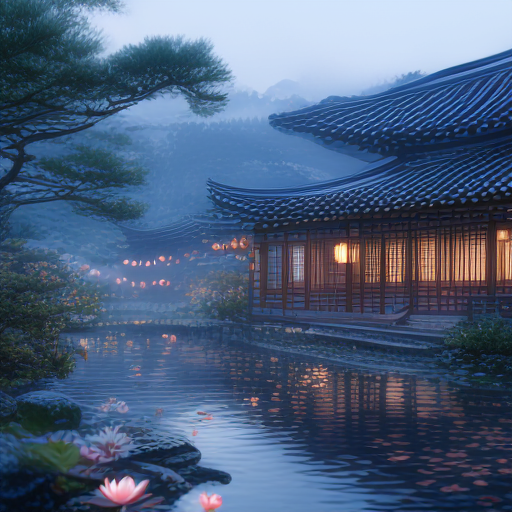

In [6]:
with torch.inference_mode():
    solver = Euler_Solver(noise_schedule,
            steps=NFE,
            skip_type="time_uniform_flow",
            flow_shift=3.0,
            algorithm_type="vector_prediction").to(model.device)
    euler_latents = solver.sample(latents, model_fn)['samples']
    euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]

